# 01. EDA : Batch 1 · 2 · 3 비교

- 데이터 : MIT-Stanford Battery Dataset (Severson et al., Nature Energy 2019)
- Batch 1 = 2017-05-12, Batch 2 = 2018-02-20, Batch 3 = 2018-04-12
- 원본 `.mat` 은 `src/preprocess.py` 로 셀 단위 pickle(`data/processed/`)로 변환해 두고 사용한다.

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import cm, colors

from features import (load_cells, cell_table, delta_q, knee_point, parse_policy,
                      VDLIN, EOL_AH, BATCH_LABEL, BATCH_DATE, _clean_qd)

FONT = '/System/Library/Fonts/AppleSDGothicNeo.ttc'
fm.fontManager.addfont(FONT)
plt.rcParams['font.family'] = fm.FontProperties(fname=FONT).get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

FIG = '../results/figures'
import os; os.makedirs(FIG, exist_ok=True)
BC = {'b1': '#2a6fdb', 'b2': '#e8743b', 'b3': '#19a979'}
BATCHES = ['b1', 'b2', 'b3']
pd.set_option('display.width', 200)

## 0. 데이터 정리 : 셀 제외 기준과 수명값 검증

In [2]:
cells = load_cells()
df = cell_table(cells)
print(df.groupby(['batch', 'exclude']).size().unstack(fill_value=0))

exclude      no_life  noisy  not_finished
batch                                    
b1       41        0      0             5
b2       39        8      0             0
b3       40        2      4             0


In [3]:
# cycle_life 가 '방전 용량이 0.88Ah(공칭 1.1Ah 의 80%) 밑으로 처음 내려간 사이클' 과 맞는지 확인
rows = []
for k, c in cells.items():
    s = c['summary']; qd = _clean_qd(s['QD']); cyc = s['cycle']
    below = np.where(qd < EOL_AH)[0]
    rows.append({'cell': k, 'batch': c['batch'], 'life_raw': c['life_raw'],
                 'first_below_0.88': cyc[below[0]] if len(below) else np.nan,
                 'last_cycle': cyc[-1], 'min_QD': np.nanmin(qd), 'exclude': c['exclude']})
chk = pd.DataFrame(rows)
# Batch 1·3 은 EOL 직전에서 기록이 끝난다 (life = last_cycle + 1, min_QD ≈ 0.880)
chk['life_eq_last+1'] = chk['life_raw'] == chk['last_cycle'] + 1
print(chk.groupby('batch')[['life_eq_last+1']].mean())
print()
print('min_QD 가 0.885 를 넘는데 life 가 있는 셀 (= 80% 도달 전에 기록이 끝남)')
print(chk[(chk.min_QD > 0.885) & chk.life_raw.notna()].round(3).to_string(index=False))

       life_eq_last+1
batch                
b1           1.000000
b2           0.000000
b3           0.956522

min_QD 가 0.885 를 넘는데 life 가 있는 셀 (= 80% 도달 전에 기록이 끝남)
 cell batch  life_raw  first_below_0.88  last_cycle  min_QD      exclude  life_eq_last+1
 b1c0    b1    1190.0               NaN      1189.0   1.008                         True
 b1c1    b1    1179.0               NaN      1178.0   1.038                         True
 b1c2    b1    1177.0               NaN      1176.0   1.043                         True
 b1c3    b1    1226.0               NaN      1225.0   0.971                         True
 b1c4    b1    1227.0               NaN      1226.0   1.022                         True
 b1c8    b1     879.0               NaN       878.0   0.969 not_finished            True
b1c10    b1     906.0               NaN       905.0   0.961 not_finished            True
b1c12    b1     902.0               NaN       901.0   0.913 not_finished            True
b1c13    b1     897.0             

- Batch 1·3 은 방전 용량이 0.88Ah 에 닿기 직전 사이클까지만 기록돼 있고 `cycle_life = 마지막 사이클 + 1` 이다.
- Batch 1 의 c0~c4 는 2017-06-30 배치에서 측정이 이어진 셀이라 이 파일의 수명값(1177~1227)은 잘린 값이다. 논문 공식 저장소(`Load Data.ipynb`)의 보정값(+662, +981, +1060, +208, +482)을 더해 `life` 로 쓴다.
- Batch 1 의 c8·c10·c12·c13·c22 는 최소 용량이 0.91~0.97Ah 로 80% 에 도달하지 않았다. 공식 저장소와 같이 제외한다.
- Batch 2 는 0.88Ah 아래로 내려간 뒤에도 측정이 이어지며, `cycle_life` 는 처음 0.88 밑으로 내려간 사이클과 일치한다. 수명값이 없는 8개(VarCharge 4, SLOWCYCLE 4)는 제외한다.
- Batch 3 는 공식 저장소가 noisy channel 로 제외한 6개를 제외한다(이 중 c23·c32 는 수명값도 없음).

In [4]:
use = df[df.exclude == ''].copy()
summary = use.groupby('batch').agg(cells=('cell', 'size'),
                                   newstructure=('newstructure', 'sum'),
                                   policies=('policy', 'nunique'),
                                   life_min=('life', 'min'), life_median=('life', 'median'),
                                   life_max=('life', 'max'))
summary

,cells,newstructure,policies,life_min,life_median,life_max
batch,,,,,,
b1,41,0,22,534.0,842.0,2237.0
b2,39,9,12,392.0,472.0,1186.0
b3,40,40,8,541.0,964.5,1935.0


### 0-1. 데이터 품질 점검 (사이클 단위)

In [5]:
rows = []
for b in BATCHES:
    ks = use[use.batch == b].cell
    n_cyc = spike = ir0 = temp_bad = ct_bad = 0
    for k in ks:
        s = cells[k]['summary']; m = s['cycle'] >= 2
        qd = s['QD'][m]; n_cyc += m.sum()
        spike += ((qd < 0.5) | (qd > 1.3)).sum()
        ir0 += (s['IR'][m] <= 0).sum()
        temp_bad += ((s['Tavg'][m] < 20) | (s['Tavg'][m] > 50)).sum()
        ct_bad += ((s['chargetime'][m] <= 0) | (s['chargetime'][m] > 60)).sum()
    rows.append({'batch': b, 'cells': len(ks), 'cycles': n_cyc, 'QD 스파이크(<0.5 또는 >1.3Ah)': spike,
                 'IR=0 (미측정)': ir0, 'Tavg 범위 밖(<20, >50℃)': temp_bad, 'chargetime 이상(<=0, >60분)': ct_bad})
quality = pd.DataFrame(rows).set_index('batch')
quality

,cells,cycles,QD 스파이크(<0.5 또는 >1.3Ah),IR=0 (미측정),"Tavg 범위 밖(<20, >50℃)","chargetime 이상(<=0, >60분)"
batch,,,,,,
b1,41,34300,2,18,0,6
b2,39,22995,0,4439,0,10
b3,40,41200,0,0,0,0


## Q1. Cycle Life 분포는 어떻게 생겼는가?

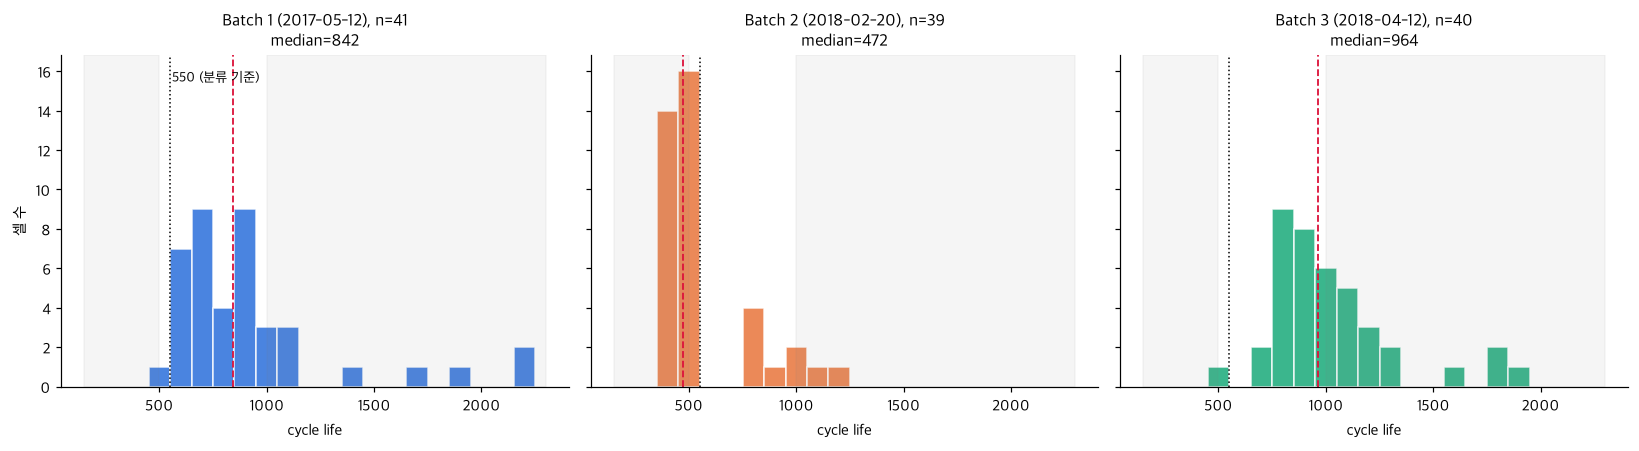

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
bins = np.arange(150, 2350, 100)
for ax, b in zip(axes, BATCHES):
    u = use[use.batch == b]
    ax.hist(u.life, bins=bins, color=BC[b], alpha=0.85, edgecolor='white')
    ax.axvspan(150, 500, color='grey', alpha=0.08); ax.axvspan(1000, 2300, color='grey', alpha=0.08)
    ax.axvline(550, color='k', ls=':', lw=1)
    ax.axvline(u.life.median(), color='crimson', ls='--', lw=1.2)
    ax.set_title(f'{BATCH_LABEL[b]} ({BATCH_DATE[b]}), n={len(u)}\nmedian={u.life.median():.0f}', fontsize=11)
    ax.set_xlabel('cycle life')
axes[0].set_ylabel('셀 수')
axes[0].text(560, axes[0].get_ylim()[1]*0.92, '550 (분류 기준)', fontsize=9)
plt.tight_layout(); plt.savefig(f'{FIG}/q1_life_hist.png', bbox_inches='tight'); plt.show()

In [7]:
def life_group(x):
    return '단수명(<500)' if x < 500 else ('장수명(>1000)' if x > 1000 else '중간(500~1000)')
ratio = (use.assign(group=use.life.map(life_group))
            .groupby(['batch', 'group']).size().unstack(fill_value=0))
ratio['단수명 비율'] = (ratio['단수명(<500)'] / ratio.sum(axis=1)).round(2)
ratio['장수명 비율'] = (ratio['장수명(>1000)'] / ratio[['단수명(<500)', '중간(500~1000)', '장수명(>1000)']].sum(axis=1)).round(2)
ratio['550 미만'] = use.groupby('batch').apply(lambda u: (u.life < 550).sum())
ratio

group,단수명(<500),장수명(>1000),중간(500~1000),단수명 비율,장수명 비율,550 미만
batch,,,,,,
b1,0,10,31,0.00,0.24,1
b2,28,3,8,0.72,0.08,30
b3,0,19,21,0.00,0.48,1


In [8]:
# 배치 안에서 유독 짧은 셀 : log10(life) 기준 IQR 하한 밖, 또는 배치 내 하위 5%
out = []
for b in BATCHES:
    u = use[use.batch == b]
    q1, q3 = u.log_life.quantile([0.25, 0.75]); lo = q1 - 1.5 * (q3 - q1)
    for _, r in u[(u.log_life < lo) | (u.life <= u.life.quantile(0.05))].iterrows():
        out.append({'batch': b, 'cell': r.cell, 'life': r.life, 'policy': r.policy,
                    'avg_crate': round(r.avg_crate, 2), 'batch_median': u.life.median(),
                    'iqr_outlier': r.log_life < lo})
pd.DataFrame(out)

,batch,cell,life,policy,avg_crate,batch_median,iqr_outlier
0,b1,b1c20,534.0,5.4C(80%)-5.4C,5.40,842.0,False
1,b1,b1c21,559.0,5.4C(80%)-5.4C,5.40,842.0,False
2,b1,b1c45,599.0,8C(35%)-3.6C,4.74,842.0,False
3,b2,b2c6,393.0,3.6C(9%)-5C,4.79,472.0,False
4,b2,b2c19,392.0,6C(60%)-3C,4.80,472.0,False
5,b3,b3c6,667.0,3.7C(31%)-5.9C-newstructure,4.80,964.5,False
6,b3,b3c28,541.0,3.7C(31%)-5.9C-newstructure,4.80,964.5,False


In [9]:
# 같은 정책끼리 수명 차이 (Batch 1 은 정책당 1~2개 셀)
b1 = use[use.batch == 'b1']
pair = b1.groupby('policy').life.agg(['count', 'min', 'max'])
pair['ratio'] = (pair['max'] / pair['min']).round(2)
pair.sort_values('ratio', ascending=False).head(6)

,count,min,max,ratio
policy,,,,
4.8C(80%)-4.8C,2,636.0,870.0,1.37
6C(50%)-3.6C,2,709.0,876.0,1.24
5.4C(60%)-3C,2,719.0,880.0,1.22
3.6C(80%)-3.6C,3,1852.0,2237.0,1.21
4C(80%)-4C,2,1434.0,1709.0,1.19
6C(40%)-3C,2,854.0,1017.0,1.19


In [10]:
# Batch 1 : 평균 충전속도(0~80%)가 가장 빠른 정책 순서
b1[['cell', 'policy', 'avg_crate', 'life']].sort_values('avg_crate', ascending=False).head(8)

,cell,policy,avg_crate,life
21,b1c21,5.4C(80%)-5.4C,5.400000,559.0
20,b1c20,5.4C(80%)-5.4C,5.400000,534.0
19,b1c19,5.4C(70%)-3C,4.909091,788.0
18,b1c18,5.4C(70%)-3C,4.909091,691.0
17,b1c17,5.4C(60%)-3.6C,4.800000,857.0
33,b1c33,6C(60%)-3C,4.800000,757.0
32,b1c32,6C(60%)-3C,4.800000,731.0
31,b1c31,6C(50%)-3.6C,4.800000,876.0


### Q1-보강. 기술통계 · log 변환 · 정책 내 변동

In [11]:
from scipy.stats import skew as _skew, kurtosis as _kurt
def desc(x):
    return pd.Series({'n': len(x), 'mean': x.mean(), 'median': x.median(), 'std': x.std(),
                      'CV': x.std() / x.mean(), 'Q1': x.quantile(.25), 'Q3': x.quantile(.75),
                      'IQR': x.quantile(.75) - x.quantile(.25), 'skew': _skew(x), 'kurtosis': _kurt(x)})
stats_life = use.groupby('batch').life.apply(desc).unstack().round(2)
stats_log = use.groupby('batch').log_life.apply(desc).unstack()[['skew', 'kurtosis']].round(2)
print('cycle life'); print(stats_life.to_string())
print('\nlog10(cycle life) 의 왜도·첨도'); print(stats_log.to_string())

cycle life
          n     mean  median     std    CV      Q1       Q3    IQR  skew  kurtosis
batch                                                                             
b1     41.0   921.34   842.0  400.77  0.43  702.00   966.00  264.0  2.06      3.62
b2     39.0   565.74   472.0  222.20  0.39  439.50   508.50   69.0  1.57      1.12
b3     40.0  1032.00   964.5  308.60  0.30  827.25  1122.75  295.5  1.47      1.90

log10(cycle life) 의 왜도·첨도
       skew  kurtosis
batch                
b1     1.31      1.32
b2     1.30      0.24
b3     0.67      0.70


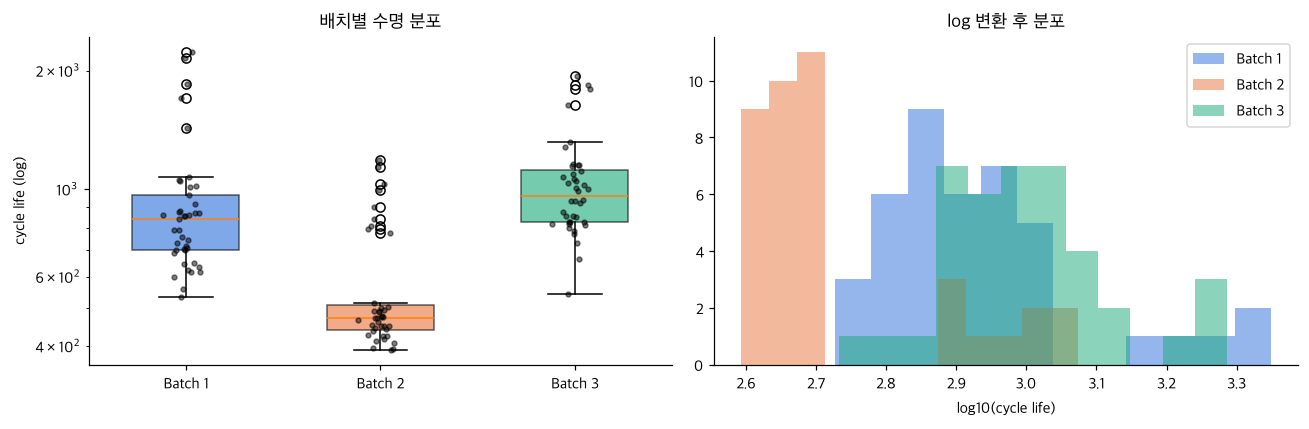

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = [use[use.batch == b].life for b in BATCHES]
bp = axes[0].boxplot(data, patch_artist=True, widths=0.55)
for patch, b in zip(bp['boxes'], BATCHES): patch.set_facecolor(BC[b]); patch.set_alpha(0.6)
for i, b in enumerate(BATCHES):
    u = use[use.batch == b]
    axes[0].scatter(np.random.default_rng(0).normal(i + 1, 0.05, len(u)), u.life, s=10, color='k', alpha=0.5, zorder=3)
axes[0].set_xticklabels([BATCH_LABEL[b] for b in BATCHES]); axes[0].set_yscale('log'); axes[0].set_ylabel('cycle life (log)')
axes[0].set_title('배치별 수명 분포')
for b in BATCHES:
    axes[1].hist(use[use.batch == b].log_life, bins=12, alpha=0.5, color=BC[b], label=BATCH_LABEL[b])
axes[1].set_xlabel('log10(cycle life)'); axes[1].legend(); axes[1].set_title('log 변환 후 분포')
plt.tight_layout(); plt.savefig(f'{FIG}/q1_box_log.png', bbox_inches='tight'); plt.show()

In [13]:
# 같은 정책 셀의 평균으로 각 셀을 예측했을 때의 오차 (leave-one-out, 정책당 2개 이상)
# = 충전 정책만 알 때 남는 셀 간 변동의 크기
rows = []
for b in BATCHES:
    u = use[use.batch == b]
    for pol, g in u.groupby('policy'):
        if len(g) < 2: continue
        for idx, r in g.iterrows():
            pred = g.drop(idx).life.mean()
            rows.append({'batch': b, 'policy': pol, 'ape': abs(pred - r.life) / r.life * 100})
loo = pd.DataFrame(rows)
print('정책 평균으로 예측한 MAPE (%):', loo.groupby('batch').ape.mean().round(1).to_dict(),
      '| 셀 수:', loo.groupby('batch').size().to_dict())
cv_pol = use.groupby(['batch', 'policy']).life.agg(['count', 'mean', 'std']).query('count >= 2')
print('정책 내 변동계수 CV 중앙값:', (cv_pol['std'] / cv_pol['mean']).groupby('batch').median().round(3).to_dict())

정책 평균으로 예측한 MAPE (%): {'b1': 10.3, 'b2': 7.9, 'b3': 18.3} | 셀 수: {'b1': 37, 'b2': 39, 'b3': 40}
정책 내 변동계수 CV 중앙값: {'b1': 0.056, 'b2': 0.047, 'b3': 0.165}


## Q2. 열화 곡선 : 방전 용량이 어떻게 감소하는가?

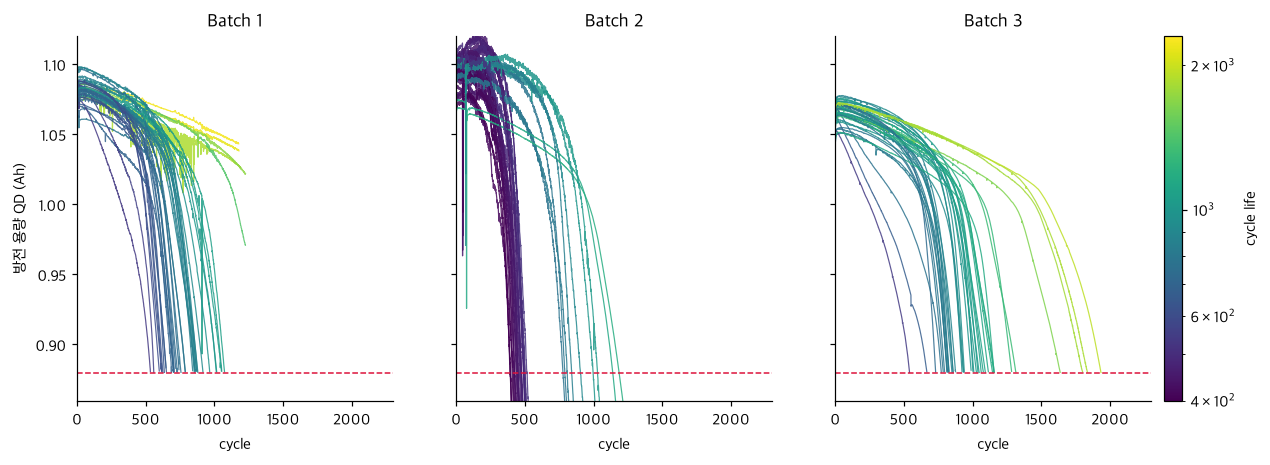

In [14]:
norm = colors.LogNorm(vmin=400, vmax=2300); cmap = cm.viridis
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for ax, b in zip(axes, BATCHES):
    for _, r in use[use.batch == b].iterrows():
        s = cells[r.cell]['summary']; qd = _clean_qd(s['QD'])
        ax.plot(s['cycle'], qd, color=cmap(norm(r.life)), lw=0.8, alpha=0.85)
    ax.axhline(EOL_AH, color='crimson', ls='--', lw=1)
    ax.set_title(BATCH_LABEL[b]); ax.set_xlabel('cycle'); ax.set_xlim(0, 2300); ax.set_ylim(0.86, 1.12)
axes[0].set_ylabel('방전 용량 QD (Ah)')
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label='cycle life', pad=0.01)
plt.savefig(f'{FIG}/q2_fade_curves.png', bbox_inches='tight'); plt.show()

In [15]:
# 열화 속도 : 초기 구간(2~100) 과 EOL 직전 100사이클의 기울기 비교 (Ah/100cycle)
rate = []
for _, r in use.iterrows():
    c = cells[r.cell]; s = c['summary']; qd = pd.Series(_clean_qd(s['QD']), index=s['cycle'])
    end = c['life_raw']
    early = qd.loc[2:100].dropna(); late = qd.loc[end-100:end-1].dropna()
    e = np.polyfit(early.index, early.values, 1)[0] * 100
    l = np.polyfit(late.index, late.values, 1)[0] * 100 if len(late) > 20 else np.nan
    knee, _ = knee_point(c)
    rate.append({'cell': r.cell, 'batch': r.batch, 'life': r.life, 'carryover': r.carryover,
                 'slope_early': e, 'slope_late': l, 'knee': knee,
                 'qd_change_2_100_pct': (qd.loc[100] / qd.loc[2] - 1) * 100})
rate = pd.DataFrame(rate)
# carryover 셀(c0~c4)은 이 파일에 EOL 구간이 없으므로 late·knee 계산에서 제외
r_ok = rate[~rate.carryover]
print(r_ok.groupby('batch')[['slope_early', 'slope_late', 'qd_change_2_100_pct']].median().round(4))
print('\nlate/early 기울기 비 (중앙값):', (r_ok.slope_late / r_ok.slope_early).groupby(r_ok.batch).median().round(1).to_dict())

       slope_early  slope_late  qd_change_2_100_pct
batch                                              
b1         -0.0007     -0.0952               0.2202
b2          0.0022     -0.1465               0.1977
b3         -0.0007     -0.0931               0.1297

late/early 기울기 비 (중앙값): {'b1': 53.8, 'b2': -16.1, 'b3': 61.3}


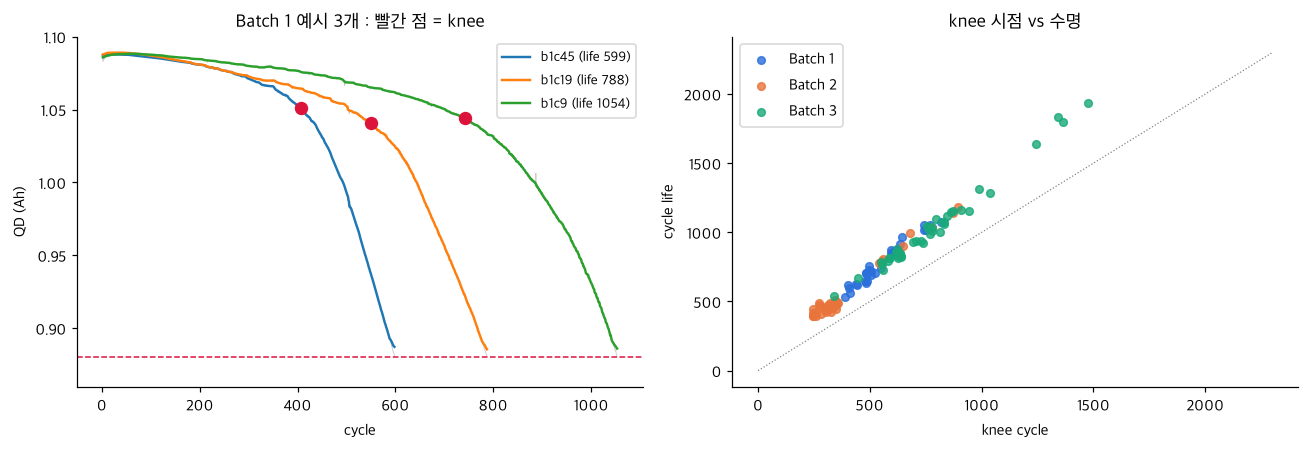

        50%   min   max
batch                  
b1     0.71  0.65  0.76
b2     0.69  0.55  0.78
b3     0.75  0.63  0.82
corr(knee, life): {'b1': np.float64(0.981), 'b2': np.float64(0.989), 'b3': np.float64(0.992)}


In [16]:
r_ok = r_ok.assign(knee_frac=r_ok.knee / r_ok.life)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ex = use[(use.batch == 'b1') & (~use.carryover)].sort_values('life').iloc[[2, 18, 34]]
for _, r in ex.iterrows():
    k, sm = knee_point(cells[r.cell])
    s = cells[r.cell]['summary']
    axes[0].plot(s['cycle'], _clean_qd(s['QD']), lw=0.6, alpha=0.4, color='grey')
    axes[0].plot(sm.index, sm.values, lw=1.6, label=f'{r.cell} (life {r.life:.0f})')
    axes[0].scatter([k], [sm.loc[k]], s=60, zorder=5, color='crimson')
axes[0].axhline(EOL_AH, color='crimson', ls='--', lw=1)
axes[0].set_xlabel('cycle'); axes[0].set_ylabel('QD (Ah)'); axes[0].set_ylim(0.86, 1.1)
axes[0].set_title('Batch 1 예시 3개 : 빨간 점 = knee'); axes[0].legend(fontsize=9)
for b in BATCHES:
    u = r_ok[r_ok.batch == b]
    axes[1].scatter(u.knee, u.life, color=BC[b], label=BATCH_LABEL[b], alpha=0.8, s=25)
lim = [0, 2300]; axes[1].plot(lim, lim, color='grey', lw=0.8, ls=':')
axes[1].set_xlabel('knee cycle'); axes[1].set_ylabel('cycle life'); axes[1].legend()
axes[1].set_title('knee 시점 vs 수명')
plt.tight_layout(); plt.savefig(f'{FIG}/q2_knee.png', bbox_inches='tight'); plt.show()
print(r_ok.groupby('batch').knee_frac.describe()[['50%', 'min', 'max']].round(2))
print('corr(knee, life):', {b: round(r_ok[r_ok.batch == b][['knee', 'life']].corr().iloc[0, 1], 3) for b in BATCHES})

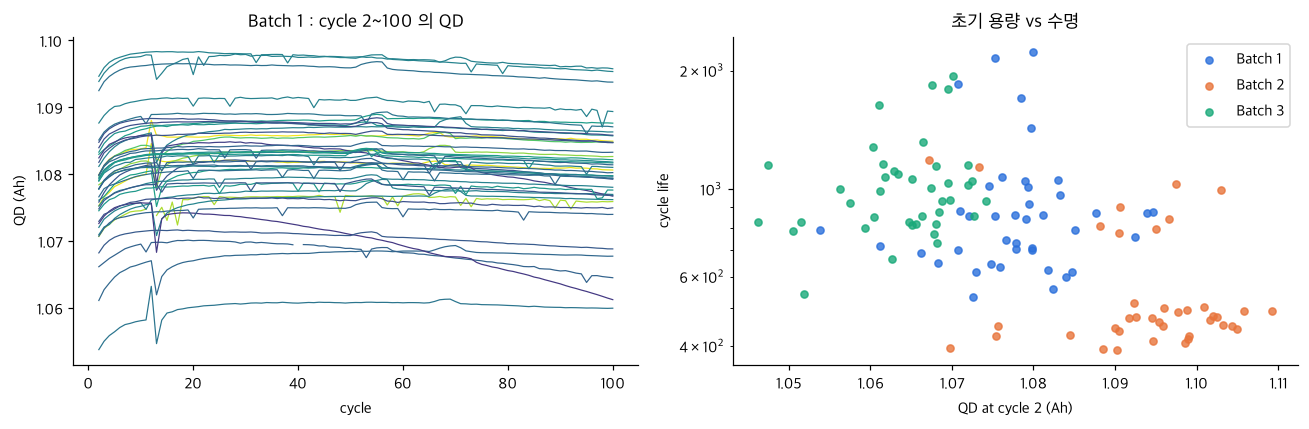

corr(qd_c2, log_life): {'b1': np.float64(0.035), 'b2': np.float64(-0.225), 'b3': np.float64(0.259)}


In [17]:
# 초기 100 사이클 구간 확대 : QD 만으로 장·단수명이 갈리는가?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for _, r in use[use.batch == 'b1'].iterrows():
    s = cells[r.cell]['summary']; qd = _clean_qd(s['QD']); m = (s['cycle'] >= 2) & (s['cycle'] <= 100)
    axes[0].plot(s['cycle'][m], qd[m], color=cmap(norm(r.life)), lw=0.8)
axes[0].set_title('Batch 1 : cycle 2~100 의 QD'); axes[0].set_xlabel('cycle'); axes[0].set_ylabel('QD (Ah)')
for b in BATCHES:
    u = use[use.batch == b]
    axes[1].scatter(u.qd_c2, u.life, color=BC[b], label=BATCH_LABEL[b], s=22, alpha=0.8)
axes[1].set_xlabel('QD at cycle 2 (Ah)'); axes[1].set_ylabel('cycle life'); axes[1].set_yscale('log'); axes[1].legend()
axes[1].set_title('초기 용량 vs 수명')
plt.tight_layout(); plt.savefig(f'{FIG}/q2_early_qd.png', bbox_inches='tight'); plt.show()
print('corr(qd_c2, log_life):', {b: round(use[use.batch == b][['qd_c2', 'log_life']].corr().iloc[0, 1], 3) for b in BATCHES})

### Q2-보강. 수명으로 정규화한 열화 곡선과 구간별 기울기

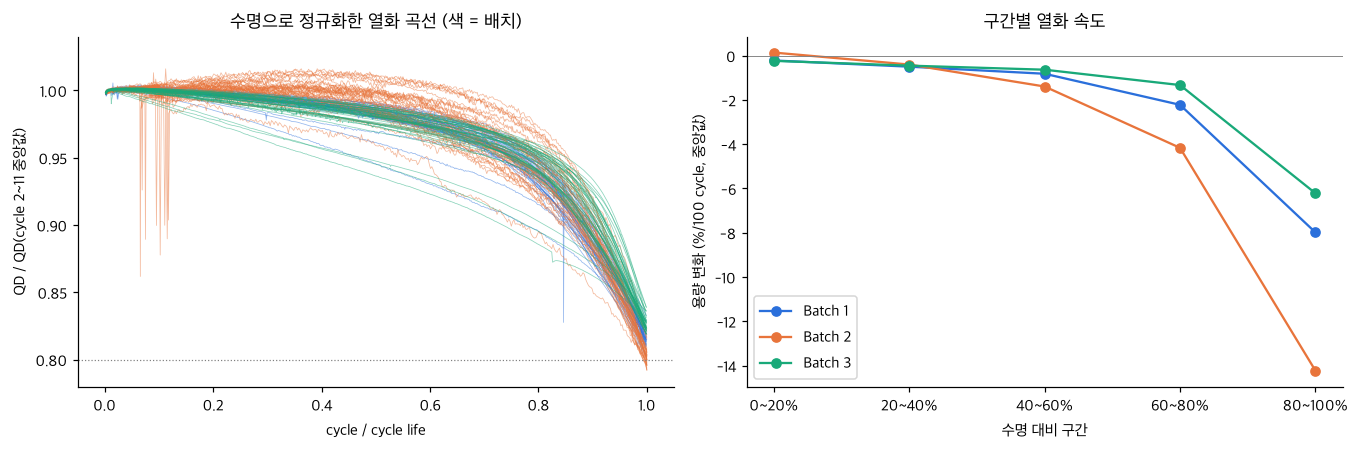

batch,b1,b2,b3
seg,,,
0~20%,-0.216,0.142,-0.233
20~40%,-0.496,-0.399,-0.449
40~60%,-0.816,-1.392,-0.632
60~80%,-2.219,-4.163,-1.326
80~100%,-7.984,-14.229,-6.215


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
seg_rows = []
for _, r in use[~use.carryover].iterrows():
    c = cells[r.cell]; s = c['summary']
    qd = pd.Series(_clean_qd(s['QD']), index=s['cycle']).loc[2:c['life_raw']].dropna()
    ref = qd.loc[2:11].median()
    x = qd.index.values / r.life; y = qd.values / ref
    axes[0].plot(x, y, color=BC[r.batch], lw=0.5, alpha=0.5)
    for lo in np.arange(0, 1.0, 0.2):
        m = (x >= lo) & (x < lo + 0.2)
        if m.sum() > 10:
            seg_rows.append({'batch': r.batch, 'seg': f'{int(lo*100)}~{int(lo*100+20)}%',
                             'slope': np.polyfit(x[m], y[m], 1)[0] / r.life * 100 * 100})  # %/100cycle
axes[0].axhline(EOL_AH / 1.1, color='grey', ls=':', lw=0.8)
axes[0].set_xlabel('cycle / cycle life'); axes[0].set_ylabel('QD / QD(cycle 2~11 중앙값)')
axes[0].set_ylim(0.78, 1.04); axes[0].set_title('수명으로 정규화한 열화 곡선 (색 = 배치)')
seg = pd.DataFrame(seg_rows).groupby(['seg', 'batch']).slope.median().unstack()
for b in BATCHES:
    axes[1].plot(seg.index, seg[b], marker='o', color=BC[b], label=BATCH_LABEL[b])
axes[1].axhline(0, color='grey', lw=0.6)
axes[1].set_xlabel('수명 대비 구간'); axes[1].set_ylabel('용량 변화 (%/100 cycle, 중앙값)'); axes[1].legend()
axes[1].set_title('구간별 열화 속도')
plt.tight_layout(); plt.savefig(f'{FIG}/q2_normalized.png', bbox_inches='tight'); plt.show()
seg.round(3)

## Q3. ΔQ(V) 곡선 : 초기 사이클에서 차이가 보이는가?

ΔQ_100-10(V) = Q_100(V) - Q_10(V). `Qdlin` 은 방전 용량을 전압축(3.5V→2.0V, 1000포인트)에 보간한 값이다.

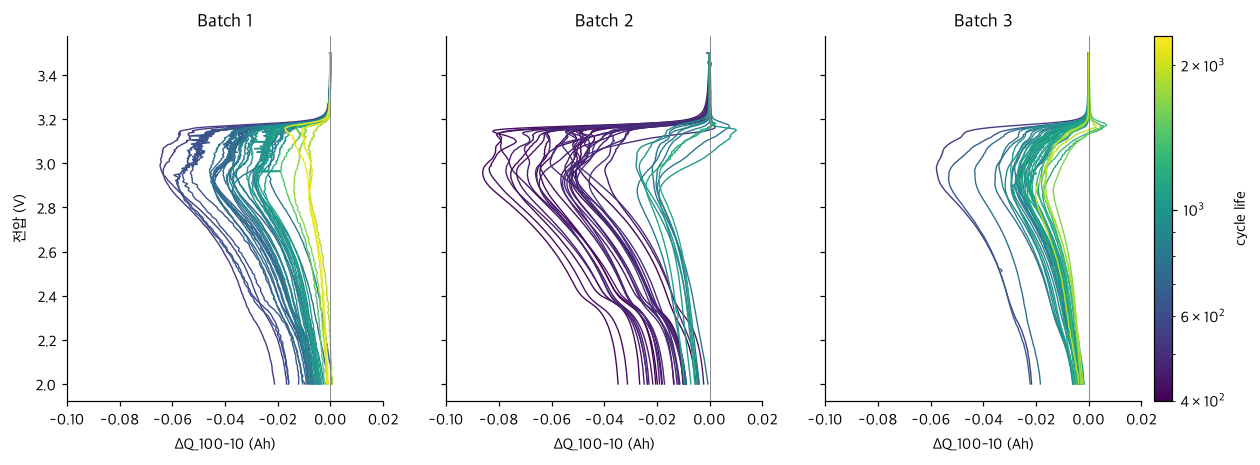

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for ax, b in zip(axes, BATCHES):
    for _, r in use[use.batch == b].sort_values('life').iterrows():
        ax.plot(delta_q(cells[r.cell]), VDLIN, color=cmap(norm(r.life)), lw=0.9)
    ax.axvline(0, color='grey', lw=0.6)
    ax.set_title(BATCH_LABEL[b]); ax.set_xlabel('ΔQ_100-10 (Ah)'); ax.set_xlim(-0.1, 0.02)
axes[0].set_ylabel('전압 (V)')
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label='cycle life', pad=0.01)
plt.savefig(f'{FIG}/q3_deltaq_curves.png', bbox_inches='tight'); plt.show()

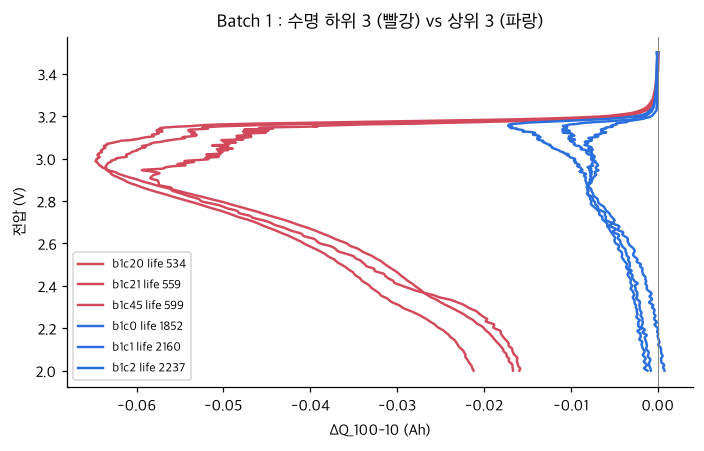

     cell    life  dq_var  dq_min  dq_mean
20  b1c20   534.0  -3.367  -1.197   -1.484
21  b1c21   559.0  -3.350  -1.189   -1.513
45  b1c45   599.0  -3.425  -1.226   -1.540
0    b1c0  1852.0  -5.015  -2.073   -2.542
1    b1c1  2160.0  -5.014  -1.958   -2.387
2    b1c2  2237.0  -4.737  -1.764   -2.348


In [20]:
# 장수명 vs 단수명 대표 셀 비교 (Batch 1)
b1u = use[use.batch == 'b1'].sort_values('life')
pick = pd.concat([b1u.head(3), b1u.tail(3)])
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for _, r in pick.iterrows():
    ax.plot(delta_q(cells[r.cell]), VDLIN, lw=1.6, label=f'{r.cell} life {r.life:.0f}',
            color='#d1495b' if r.life < 700 else '#2a6fdb')
ax.axvline(0, color='grey', lw=0.6); ax.set_xlabel('ΔQ_100-10 (Ah)'); ax.set_ylabel('전압 (V)')
ax.set_title('Batch 1 : 수명 하위 3 (빨강) vs 상위 3 (파랑)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIG}/q3_deltaq_long_short.png', bbox_inches='tight'); plt.show()
print(pick[['cell', 'life', 'dq_var', 'dq_min', 'dq_mean']].round(3))

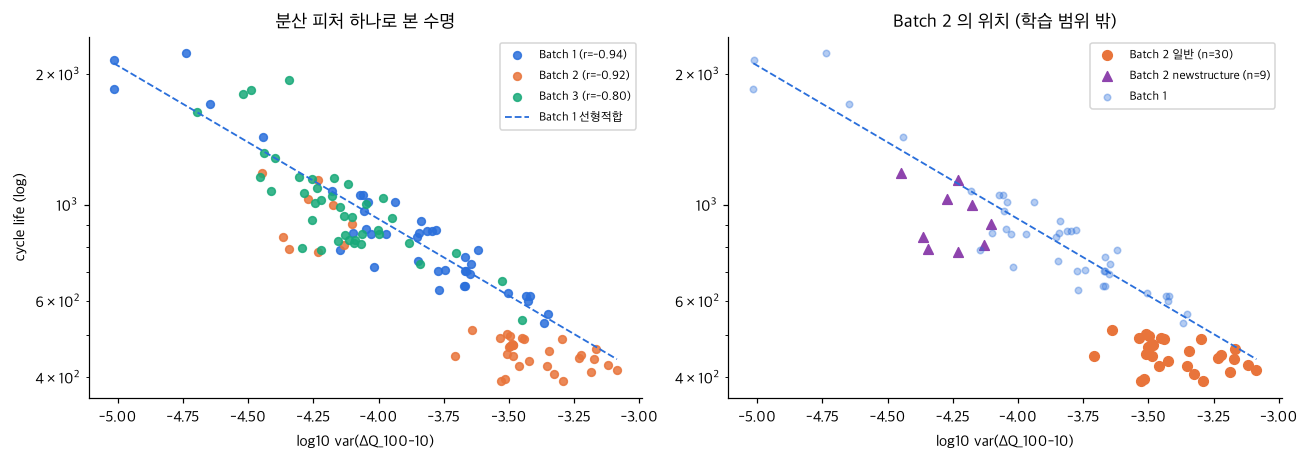

dq_var 범위: {'b1': {'min': -5.01, 'max': -3.35}, 'b2': {'min': -4.45, 'max': -3.09}, 'b3': {'min': -4.69, 'max': -3.45}}


In [21]:
# ΔQ 통계량 vs 수명 : 배치별 상관과 Batch 1 회귀선
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for b in BATCHES:
    u = use[use.batch == b]
    axes[0].scatter(u.dq_var, u.life, color=BC[b], s=26, alpha=0.85,
                    label=f'{BATCH_LABEL[b]} (r={u.dq_var.corr(u.log_life):.2f})')
u1 = use[use.batch == 'b1']; p = np.polyfit(u1.dq_var, u1.log_life, 1)
xx = np.linspace(use.dq_var.min(), use.dq_var.max(), 50)
axes[0].plot(xx, 10 ** np.polyval(p, xx), color=BC['b1'], lw=1.2, ls='--', label='Batch 1 선형적합')
axes[0].set_yscale('log'); axes[0].set_xlabel('log10 var(ΔQ_100-10)'); axes[0].set_ylabel('cycle life (log)')
axes[0].legend(fontsize=8); axes[0].set_title('분산 피처 하나로 본 수명')
# Batch 2 : newstructure 표시
u2 = use[use.batch == 'b2']
for ns, mk in [(False, 'o'), (True, '^')]:
    v = u2[u2.newstructure == ns]
    axes[1].scatter(v.dq_var, v.life, marker=mk, s=40, color=BC['b2'] if not ns else '#8e44ad',
                    label=f'Batch 2 {"newstructure" if ns else "일반"} (n={len(v)})')
axes[1].scatter(u1.dq_var, u1.life, s=18, color=BC['b1'], alpha=0.35, label='Batch 1')
axes[1].plot(xx, 10 ** np.polyval(p, xx), color=BC['b1'], lw=1.2, ls='--')
axes[1].set_yscale('log'); axes[1].set_xlabel('log10 var(ΔQ_100-10)'); axes[1].legend(fontsize=8)
axes[1].set_title('Batch 2 의 위치 (학습 범위 밖)')
plt.tight_layout(); plt.savefig(f'{FIG}/q3_dqvar_vs_life.png', bbox_inches='tight'); plt.show()
print('dq_var 범위:', use.groupby('batch').dq_var.agg(['min', 'max']).round(2).to_dict('index'))

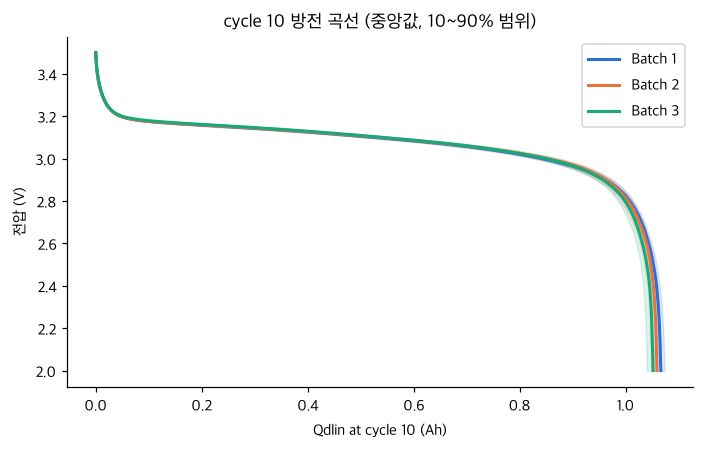

b1 Qdlin(c10) @3.3V median 0.0118  @2.0V median 1.0666
b2 Qdlin(c10) @3.3V median 0.012  @2.0V median 1.0593
b3 Qdlin(c10) @3.3V median 0.0125  @2.0V median 1.0519


In [22]:
# 배치별 Qdlin(cycle 10) 절대값 비교 : 배치마다 곡선 위치가 다른가?
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for b in BATCHES:
    Q = np.vstack([cells[k]['Qdlin'][9] for k in use[use.batch == b].cell])
    ax.plot(np.nanmedian(Q, axis=0), VDLIN, color=BC[b], lw=2, label=BATCH_LABEL[b])
    ax.fill_betweenx(VDLIN, np.nanpercentile(Q, 10, axis=0), np.nanpercentile(Q, 90, axis=0), color=BC[b], alpha=0.15)
ax.set_xlabel('Qdlin at cycle 10 (Ah)'); ax.set_ylabel('전압 (V)'); ax.legend()
ax.set_title('cycle 10 방전 곡선 (중앙값, 10~90% 범위)')
plt.tight_layout(); plt.savefig(f'{FIG}/q3_qdlin_batches.png', bbox_inches='tight'); plt.show()
for b in BATCHES:
    Q = np.vstack([cells[k]['Qdlin'][9] for k in use[use.batch == b].cell])
    print(b, 'Qdlin(c10) @3.3V median', round(float(np.nanmedian(Q[:, np.argmin(abs(VDLIN-3.3))])), 4),
          ' @2.0V median', round(float(np.nanmedian(Q[:, -1])), 4))

### Q3-보강. 신호는 어느 전압대에서, 몇 사이클부터 생기는가

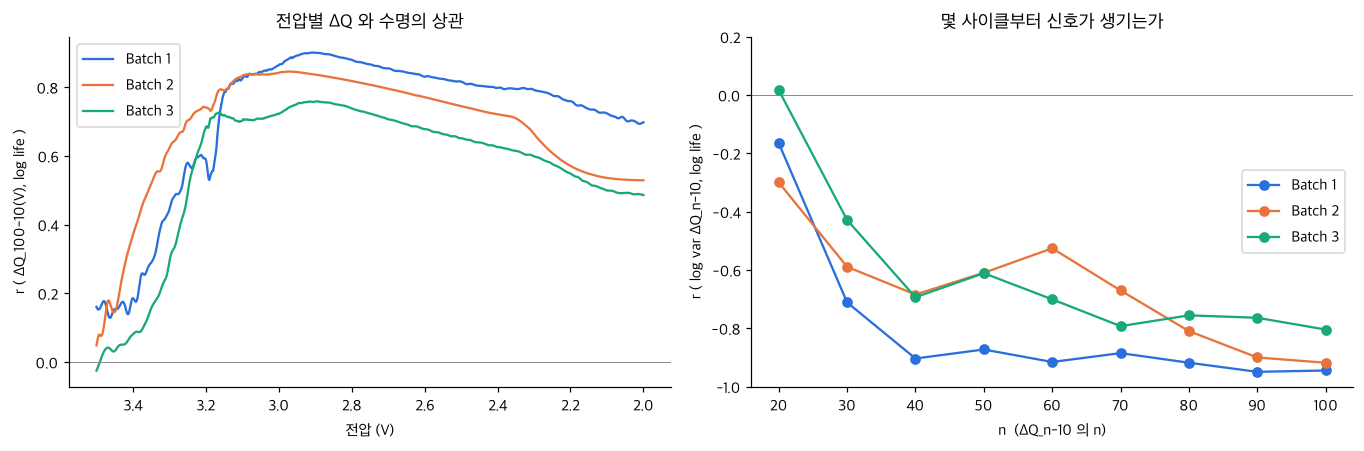

batch     b1     b2     b3
hi                        
5     -0.010  0.030 -0.253
20    -0.165 -0.300  0.017
30    -0.711 -0.589 -0.429
40    -0.904 -0.684 -0.694
50    -0.873 -0.610 -0.611
60    -0.916 -0.526 -0.701
70    -0.885 -0.671 -0.793
80    -0.918 -0.810 -0.756
90    -0.950 -0.900 -0.764
100   -0.945 -0.918 -0.805


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for b in BATCHES:
    u = use[use.batch == b]
    D = np.vstack([delta_q(cells[k]) for k in u.cell])
    r = [np.corrcoef(D[:, j], u.log_life)[0, 1] if np.nanstd(D[:, j]) > 0 else np.nan for j in range(D.shape[1])]
    axes[0].plot(VDLIN, r, color=BC[b], label=BATCH_LABEL[b])
axes[0].axhline(0, color='grey', lw=0.6); axes[0].invert_xaxis()
axes[0].set_xlabel('전압 (V)'); axes[0].set_ylabel('r ( ΔQ_100-10(V), log life )'); axes[0].legend()
axes[0].set_title('전압별 ΔQ 와 수명의 상관')
pairs = [(n, 10) for n in range(20, 101, 10)]
emer = []
for b in BATCHES:
    u = use[use.batch == b]
    for hi, lo in pairs:
        v = [np.log10(np.nanvar(delta_q(cells[k], hi, lo))) for k in u.cell]
        emer.append({'batch': b, 'hi': hi, 'r': np.corrcoef(v, u.log_life)[0, 1]})
    v5 = [np.log10(np.nanvar(delta_q(cells[k], 5, 4))) for k in u.cell]
    emer.append({'batch': b, 'hi': 5, 'r': np.corrcoef(v5, u.log_life)[0, 1]})
emer = pd.DataFrame(emer)
for b in BATCHES:
    e = emer[(emer.batch == b) & (emer.hi >= 20)]
    axes[1].plot(e.hi, e.r, marker='o', color=BC[b], label=BATCH_LABEL[b])
axes[1].set_xlabel('n  (ΔQ_n-10 의 n)'); axes[1].set_ylabel('r ( log var ΔQ_n-10, log life )'); axes[1].legend()
axes[1].set_title('몇 사이클부터 신호가 생기는가'); axes[1].set_ylim(-1, 0.2); axes[1].axhline(0, color='grey', lw=0.6)
plt.tight_layout(); plt.savefig(f'{FIG}/q3_voltage_cycle.png', bbox_inches='tight'); plt.show()
print(emer.pivot(index='hi', columns='batch', values='r').round(3))

## Q4. 충전 조건(C-rate)과 수명의 관계는?

정책 `C1(Q1%)-C2` : SOC 0→Q1% 는 C1, Q1→80% 는 C2 로 충전. `avg_crate` = 0~80% 구간 평균 충전 속도 = 0.8 / (Q1/C1 + (0.8-Q1)/C2).

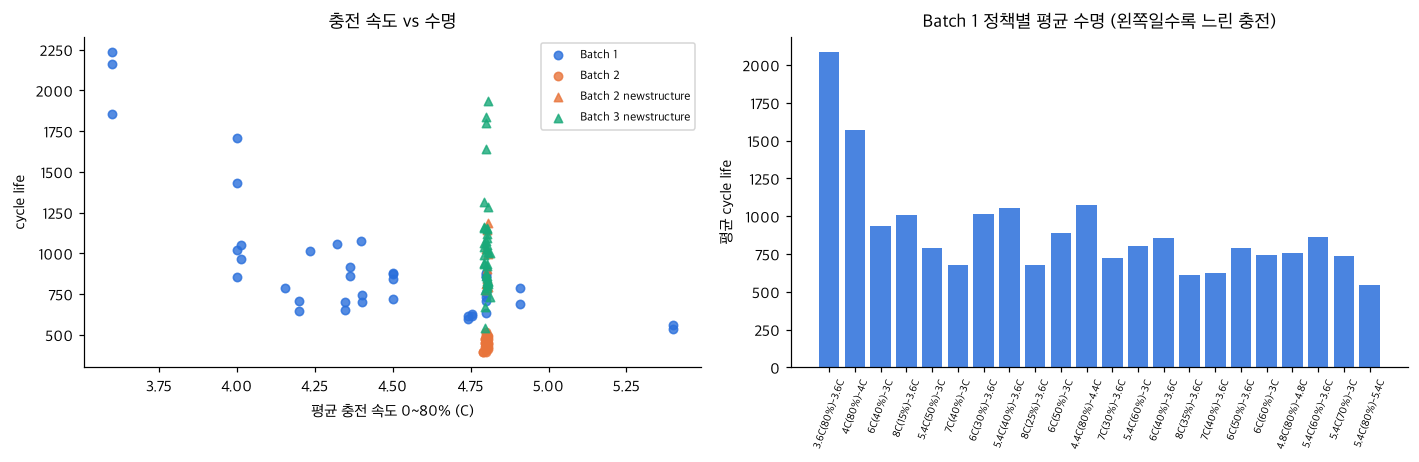

b1 corr(avg_crate, log_life) = -0.776 | corr(C1, log_life) = -0.643 | corr(avg_crate, fade_slope_2_100) = -0.615
b2 corr(avg_crate, log_life) = 0.35 | corr(C1, log_life) = 0.196 | corr(avg_crate, fade_slope_2_100) = -0.333
b3 corr(avg_crate, log_life) = -0.024 | corr(C1, log_life) = 0.07 | corr(avg_crate, fade_slope_2_100) = 0.269


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for b in BATCHES:
    u = use[use.batch == b]
    for ns, mk in [(False, 'o'), (True, '^')]:
        v = u[u.newstructure == ns]
        if len(v):
            axes[0].scatter(v.avg_crate, v.life, color=BC[b], marker=mk, s=30, alpha=0.8,
                            label=f'{BATCH_LABEL[b]}{" newstructure" if ns else ""}')
axes[0].set_xlabel('평균 충전 속도 0~80% (C)'); axes[0].set_ylabel('cycle life'); axes[0].legend(fontsize=8)
axes[0].set_title('충전 속도 vs 수명')
g = use[use.batch == 'b1'].groupby('policy').agg(life=('life', 'mean'), crate=('avg_crate', 'first'), n=('life', 'size')).sort_values('crate')
axes[1].bar(range(len(g)), g.life, color=BC['b1'], alpha=0.85)
axes[1].set_xticks(range(len(g))); axes[1].set_xticklabels(g.index, rotation=70, fontsize=7)
axes[1].set_ylabel('평균 cycle life'); axes[1].set_title('Batch 1 정책별 평균 수명 (왼쪽일수록 느린 충전)')
plt.tight_layout(); plt.savefig(f'{FIG}/q4_crate_life.png', bbox_inches='tight'); plt.show()
for b in BATCHES:
    u = use[use.batch == b]
    print(b, 'corr(avg_crate, log_life) =', round(u.avg_crate.corr(u.log_life), 3),
          '| corr(C1, log_life) =', round(u.C1.corr(u.log_life), 3),
          '| corr(avg_crate, fade_slope_2_100) =', round(u.avg_crate.corr(u.fade_slope_2_100), 3))

In [25]:
# Batch 2 : 같은 정책인데 newstructure 여부로 수명이 갈리는가?
u2 = use[use.batch == 'b2'].assign(base=lambda d: d.policy.str.replace('-newstructure', '', regex=False))
cmp_ = u2.groupby(['base', 'newstructure']).life.agg(['count', 'mean', 'min', 'max']).round(0)
cmp_

count   mean    min     max
base            newstructure                             
3.6C(30%)-6C    False             2  421.0  416.0   426.0
3.6C(9%)-5C     False             2  394.0  393.0   396.0
4.65C(44%)-5C   False             2  482.0  466.0   499.0
4.65C(69%)-6C   False             2  452.0  444.0   460.0
4.8C(80%)-4.8C  False             5  484.0  437.0   514.0
                True              3  872.0  777.0  1029.0
5.2C(50%)-4.25C False             5  454.0  424.0   474.0
5.2C(58%)-4C    False             4  478.0  452.0   493.0
                True              3  962.0  841.0  1140.0
5.6C(26%)-4.5C  False             6  448.0  412.0   491.0
                True              3  991.0  791.0  1186.0
6C(60%)-3C      False             2  400.0  392.0   408.0

In [26]:
# 충전 속도와 열화 속도 : 초기 fade 기울기, ΔQ 분산과의 상관 (Batch 1)
u = use[use.batch == 'b1']
print(u[['avg_crate', 'C1', 'Q1', 'C2', 'chargetime_avg_2_6', 'fade_slope_2_100', 'dq_var', 'tavg_mean', 'log_life']]
      .corr().loc[['avg_crate', 'C1', 'chargetime_avg_2_6'], ['fade_slope_2_100', 'dq_var', 'tavg_mean', 'log_life']].round(3))

                    fade_slope_2_100  dq_var  tavg_mean  log_life
avg_crate                     -0.615   0.798      0.208    -0.776
C1                            -0.182   0.662      0.573    -0.643
chargetime_avg_2_6             0.551  -0.818     -0.223     0.800


### Q4-보강. 2단계 정책 분해 (Batch 1) 와 같은 평균 속도 안의 정책 차이 (Batch 3)

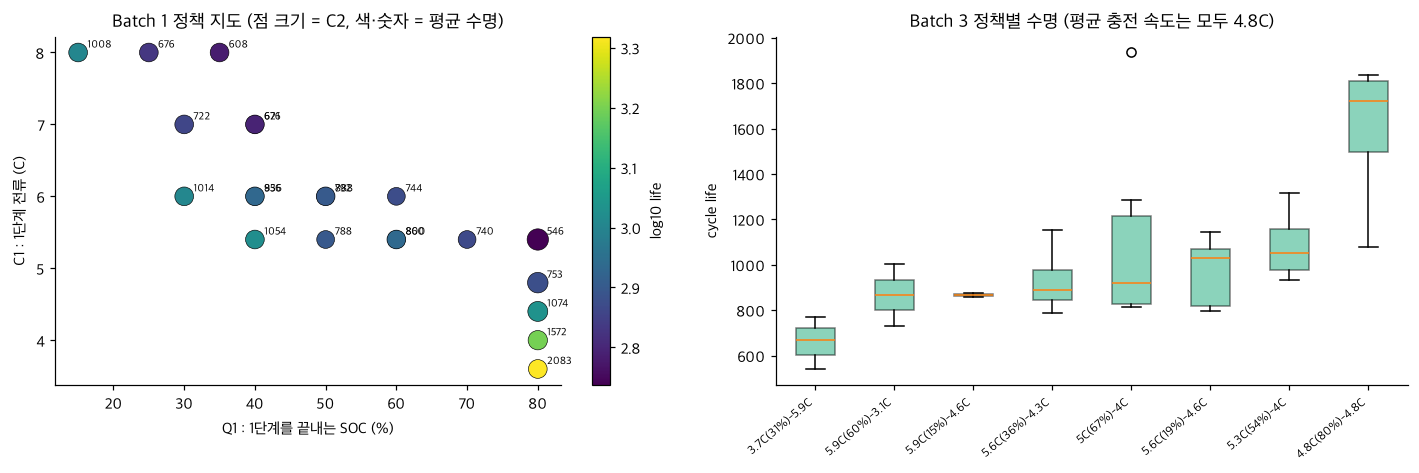

Batch 1 corr with log life: {'C1': -0.643, 'Q1': 0.352, 'C2': -0.079, 'avg_crate': -0.776}
Batch 1 단계별 충전량 비중 : 1단계가 담당하는 SOC 구간 = Q1 (%)
                             count  median     min     max
policy                                                    
3.7C(31%)-5.9C-newstructure      3   667.0   541.0   772.0
5.9C(60%)-3.1C-newstructure      2   866.0   731.0  1002.0
5.9C(15%)-4.6C-newstructure      2   867.0   858.0   876.0
5.6C(36%)-4.3C-newstructure      8   890.0   786.0  1155.0
5C(67%)-4C-newstructure          6   918.0   813.0  1935.0
5.6C(19%)-4.6C-newstructure      7  1028.0   796.0  1146.0
5.3C(54%)-4C-newstructure        8  1051.0   935.0  1315.0
4.8C(80%)-4.8C-newstructure      4  1720.0  1078.0  1836.0


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
u1 = use[use.batch == 'b1']
g = u1.groupby(['C1', 'Q1', 'C2']).life.mean().reset_index()
sc = axes[0].scatter(g.Q1, g.C1, c=np.log10(g.life), cmap='viridis', s=60 + 25 * g.C2, edgecolor='k', lw=0.4)
for _, r in g.iterrows():
    axes[0].annotate(f'{r.life:.0f}', (r.Q1, r.C1), textcoords='offset points', xytext=(6, 3), fontsize=7)
axes[0].set_xlabel('Q1 : 1단계를 끝내는 SOC (%)'); axes[0].set_ylabel('C1 : 1단계 전류 (C)')
axes[0].set_title('Batch 1 정책 지도 (점 크기 = C2, 색·숫자 = 평균 수명)')
cb = fig.colorbar(sc, ax=axes[0]); cb.set_label('log10 life')
u3 = use[use.batch == 'b3']
order = u3.groupby('policy').life.median().sort_values().index
axes[1].boxplot([u3[u3.policy == p].life for p in order], patch_artist=True,
                boxprops=dict(facecolor=BC['b3'], alpha=0.5))
axes[1].set_xticklabels([p.replace('-newstructure', '') for p in order], rotation=40, ha='right', fontsize=8)
axes[1].set_ylabel('cycle life'); axes[1].set_title('Batch 3 정책별 수명 (평균 충전 속도는 모두 4.8C)')
plt.tight_layout(); plt.savefig(f'{FIG}/q4_policy_map.png', bbox_inches='tight'); plt.show()
print('Batch 1 corr with log life:', u1[['C1', 'Q1', 'C2', 'avg_crate']].corrwith(u1.log_life).round(3).to_dict())
print('Batch 1 단계별 충전량 비중 : 1단계가 담당하는 SOC 구간 = Q1 (%)')
print(u3.groupby('policy').life.agg(['count', 'median', 'min', 'max']).sort_values('median').round(0))

## Q5. 상관관계 : 어떤 신호가 수명과 연관되어 있는가?

In [28]:
FEATS = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt', 'dq_2v',
         'qd_c2', 'qd_max_minus_c2', 'qd_c100_minus_c2', 'fade_slope_2_100', 'fade_int_2_100',
         'fade_slope_91_100', 'chargetime_avg_2_6', 'tmax_max', 'tmin_min', 'tavg_mean',
         'ir_c2', 'ir_min', 'ir_c100_minus_c2', 'avg_crate']
corr_tab = pd.DataFrame({BATCH_LABEL[b]: use[use.batch == b][FEATS].corrwith(use[use.batch == b].log_life)
                         for b in BATCHES})
corr_tab = corr_tab.reindex(corr_tab[BATCH_LABEL['b1']].abs().sort_values(ascending=False).index)
corr_tab.round(3)

,Batch 1,Batch 2,Batch 3
dq_var,-0.945,-0.918,-0.805
dq_mean,-0.917,-0.874,-0.760
dq_min,-0.916,-0.901,-0.811
chargetime_avg_2_6,0.800,-0.942,0.555
avg_crate,-0.776,0.350,-0.024
dq_2v,0.698,0.529,0.486
qd_max_minus_c2,0.557,-0.313,0.012
dq_skew,0.546,0.245,-0.250
qd_c100_minus_c2,0.518,-0.166,0.372
tavg_mean,-0.516,0.393,-0.042


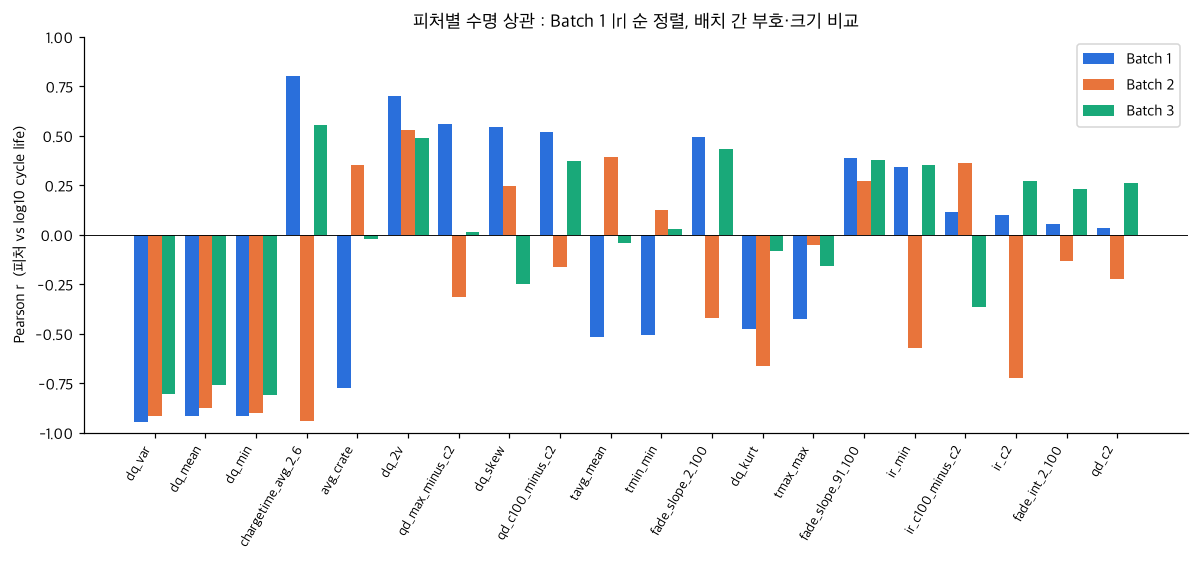

In [29]:
fig, ax = plt.subplots(figsize=(11, 5.2))
x = np.arange(len(corr_tab)); w = 0.27
for i, b in enumerate(BATCHES):
    ax.bar(x + (i - 1) * w, corr_tab[BATCH_LABEL[b]], w, color=BC[b], label=BATCH_LABEL[b])
ax.axhline(0, color='k', lw=0.6)
ax.set_xticks(x); ax.set_xticklabels(corr_tab.index, rotation=60, ha='right', fontsize=9)
ax.set_ylabel('Pearson r  (피처 vs log10 cycle life)'); ax.set_ylim(-1, 1); ax.legend()
ax.set_title('피처별 수명 상관 : Batch 1 |r| 순 정렬, 배치 간 부호·크기 비교')
plt.tight_layout(); plt.savefig(f'{FIG}/q5_corr_by_batch.png', bbox_inches='tight'); plt.show()

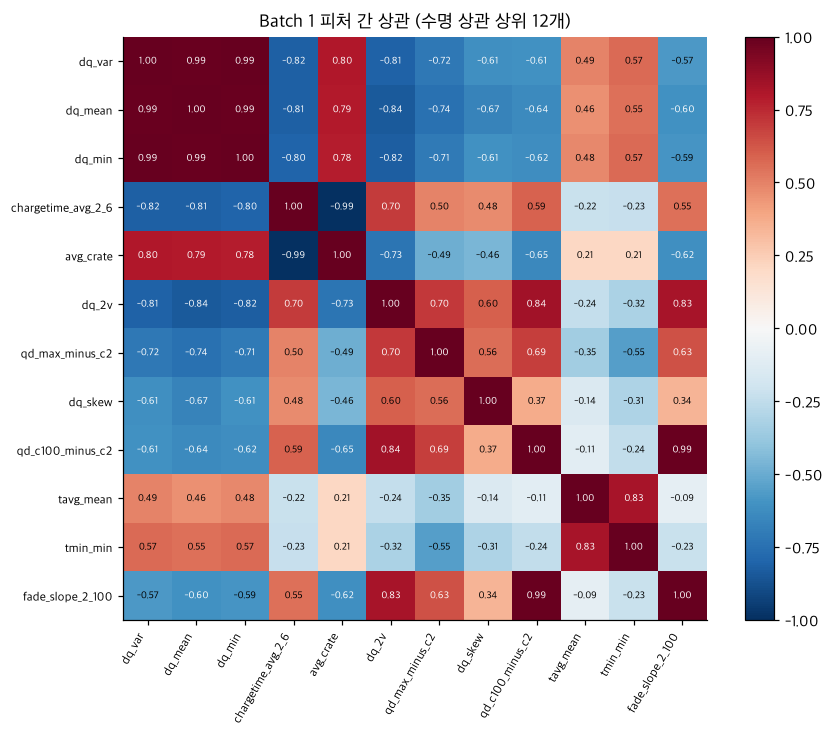

|r| > 0.8 인 피처 쌍:
  dq_var - dq_mean: 0.99
  dq_var - dq_min: 0.99
  dq_var - chargetime_avg_2_6: -0.82
  dq_var - dq_2v: -0.81
  dq_mean - dq_min: 0.99
  dq_mean - chargetime_avg_2_6: -0.81
  dq_mean - dq_2v: -0.84
  dq_min - chargetime_avg_2_6: -0.80
  dq_min - dq_2v: -0.82
  chargetime_avg_2_6 - avg_crate: -0.99
  dq_2v - qd_c100_minus_c2: 0.84
  dq_2v - fade_slope_2_100: 0.83
  qd_c100_minus_c2 - fade_slope_2_100: 0.99
  tavg_mean - tmin_min: 0.83


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [30]:
# 다중공선성 : Batch 1 피처 간 상관 히트맵
top = corr_tab.index[:12]
cm1 = use[use.batch == 'b1'][list(top)].corr()
fig, ax = plt.subplots(figsize=(8.2, 6.8))
im = ax.imshow(cm1, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(top))); ax.set_xticklabels(top, rotation=60, ha='right', fontsize=8)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top, fontsize=8)
for i in range(len(top)):
    for j in range(len(top)):
        v = cm1.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.5, color='white' if abs(v) > 0.6 else 'black')
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Batch 1 피처 간 상관 (수명 상관 상위 12개)')
plt.tight_layout(); plt.savefig(f'{FIG}/q5_feature_corr.png', bbox_inches='tight'); plt.show()
pairs = [(a, b, cm1.loc[a, b]) for i, a in enumerate(top) for b in top[i+1:] if abs(cm1.loc[a, b]) > 0.8]
print('|r| > 0.8 인 피처 쌍:'); [print(f'  {a} - {b}: {v:.2f}') for a, b, v in pairs]

In [31]:
# VIF : 각 피처를 나머지 피처로 회귀했을 때의 1/(1-R^2) (Batch 1)
from sklearn.linear_model import LinearRegression
def vif(X):
    out = {}
    for c in X.columns:
        others = X.drop(columns=c)
        r2 = LinearRegression().fit(others, X[c]).score(others, X[c])
        out[c] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(out).round(1)
cand = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt', 'qd_c2', 'qd_max_minus_c2',
        'fade_slope_2_100', 'chargetime_avg_2_6', 'tavg_mean', 'avg_crate']
print('후보 11개 :'); print(vif(use[use.batch == 'b1'][cand]).sort_values(ascending=False).to_string())
small = ['dq_var', 'dq_skew', 'qd_max_minus_c2', 'fade_slope_2_100', 'chargetime_avg_2_6', 'tavg_mean']
print('\n축소 6개 :'); print(vif(use[use.batch == 'b1'][small]).sort_values(ascending=False).to_string())

후보 11개 :
dq_min                1211.2
dq_var                 480.4
dq_mean                462.6
chargetime_avg_2_6     295.4
avg_crate              290.9
dq_kurt                 18.6
fade_slope_2_100        10.6
qd_max_minus_c2          6.3
dq_skew                  3.1
qd_c2                    2.7
tavg_mean                2.1

축소 6개 :
dq_var                7.6
chargetime_avg_2_6    3.9
qd_max_minus_c2       2.9
fade_slope_2_100      2.1
dq_skew               1.9
tavg_mean             1.7


### Q5-보강. Spearman 상관과 상위 피처 산점도 (Batch 1)

                    pearson  spearman
dq_var               -0.945    -0.882
dq_mean              -0.917    -0.836
dq_min               -0.916    -0.854
chargetime_avg_2_6    0.800     0.605
avg_crate            -0.776    -0.615
dq_2v                 0.698     0.744
qd_max_minus_c2       0.557     0.506
dq_skew               0.546     0.483
qd_c100_minus_c2      0.518     0.549
tavg_mean            -0.516    -0.389


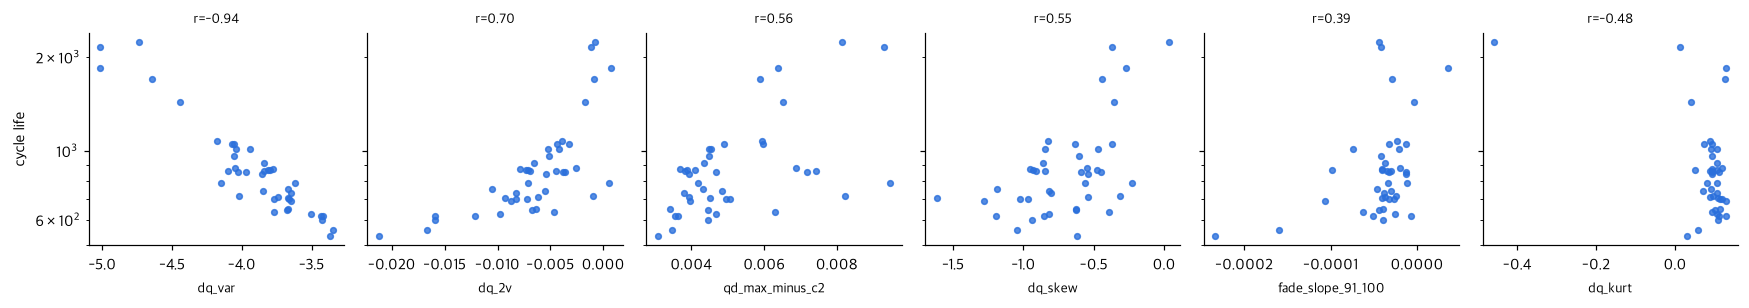

In [32]:
u1 = use[use.batch == 'b1']
sp = pd.DataFrame({'pearson': u1[FEATS].corrwith(u1.log_life), 'spearman': u1[FEATS].corrwith(u1.log_life, method='spearman')})
print(sp.reindex(sp.pearson.abs().sort_values(ascending=False).index).round(3).head(10).to_string())
top6 = ['dq_var', 'dq_2v', 'qd_max_minus_c2', 'dq_skew', 'fade_slope_91_100', 'dq_kurt']
fig, axes = plt.subplots(1, 6, figsize=(16, 2.9), sharey=True)
for ax, f in zip(axes, top6):
    ax.scatter(u1[f], u1.life, s=14, color=BC['b1'], alpha=0.8)
    ax.set_xlabel(f, fontsize=9); ax.set_title(f'r={u1[f].corr(u1.log_life):.2f}', fontsize=9)
axes[0].set_yscale('log'); axes[0].set_ylabel('cycle life')
plt.tight_layout(); plt.savefig(f'{FIG}/q5_top_scatter.png', bbox_inches='tight'); plt.show()

## 배치 간 입력 분포 차이 (라벨 미사용)

각 피처를 Batch 1 평균·표준편차로 표준화해 Batch 2·3 의 입력이 학습 분포에서 얼마나 벗어나는지 본다. 수명값은 쓰지 않는다.

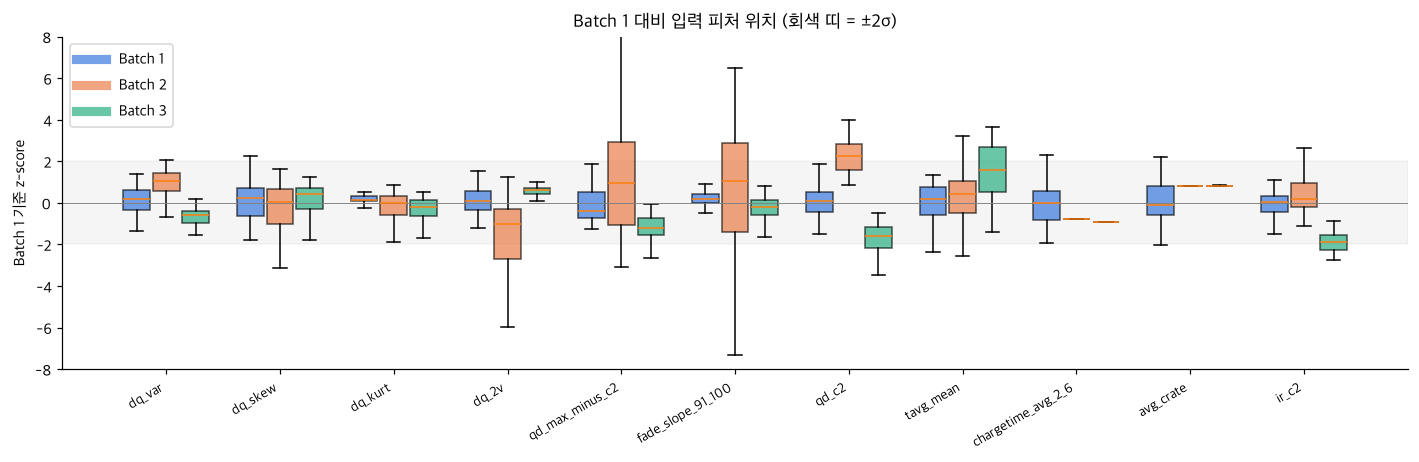

batch,b1,b2,b3,b2 범위밖 비율,b3 범위밖 비율
dq_var,0.18,1.06,-0.60,0.03,0.00
dq_skew,0.23,0.06,0.42,0.10,0.05
dq_kurt,0.15,-0.00,-0.21,0.05,0.00
dq_2v,0.08,-1.00,0.61,0.36,0.08
qd_max_minus_c2,-0.38,0.97,-1.23,0.46,0.08
fade_slope_91_100,0.18,1.07,-0.22,0.62,0.08
qd_c2,0.08,2.24,-1.59,0.59,0.35
tavg_mean,0.17,0.43,1.59,0.10,0.45
chargetime_avg_2_6,-0.02,-0.77,-0.90,0.00,0.00
avg_crate,-0.12,0.82,0.82,0.00,0.00


In [33]:
SH = ['dq_var', 'dq_skew', 'dq_kurt', 'dq_2v', 'qd_max_minus_c2', 'fade_slope_91_100',
      'qd_c2', 'tavg_mean', 'chargetime_avg_2_6', 'avg_crate', 'ir_c2']
mu, sd = use[use.batch == 'b1'][SH].mean(), use[use.batch == 'b1'][SH].std()
Z = use[SH].sub(mu).div(sd).assign(batch=use.batch)
fig, ax = plt.subplots(figsize=(13, 4.3))
w = 0.26
for i, b in enumerate(BATCHES):
    z = Z[Z.batch == b]
    pos = np.arange(len(SH)) + (i - 1) * w
    bp = ax.boxplot([z[f].dropna() for f in SH], positions=pos, widths=w * 0.9, patch_artist=True,
                    showfliers=False, manage_ticks=False)
    for patch in bp['boxes']: patch.set_facecolor(BC[b]); patch.set_alpha(0.65)
ax.axhspan(-2, 2, color='grey', alpha=0.08); ax.axhline(0, color='grey', lw=0.6)
ax.set_xticks(range(len(SH))); ax.set_xticklabels(SH, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Batch 1 기준 z-score'); ax.set_ylim(-8, 8)
for b in BATCHES: ax.plot([], [], color=BC[b], lw=6, alpha=0.65, label=BATCH_LABEL[b])
ax.legend(loc='upper left'); ax.set_title('Batch 1 대비 입력 피처 위치 (회색 띠 = ±2σ)')
plt.tight_layout(); plt.savefig(f'{FIG}/shift_inputs.png', bbox_inches='tight'); plt.show()
zmed = Z.groupby('batch')[SH].median().T.round(2)
zmed['b2 범위밖 비율'] = Z[Z.batch == 'b2'][SH].abs().gt(2).mean().round(2)
zmed['b3 범위밖 비율'] = Z[Z.batch == 'b3'][SH].abs().gt(2).mean().round(2)
zmed

In [34]:
# Batch 2 IR 결측 확인
print(use.groupby('batch').ir_c2.apply(lambda s: s.isna().sum()))
print(use[use.ir_c2.isna()][['cell', 'policy', 'life']])

batch
b1    0
b2    6
b3    0
Name: ir_c2, dtype: int64
     cell                       policy    life
87  b2c41               5.6C(26%)-4.5C   442.0
88  b2c42              5.2C(50%)-4.25C   474.0
89  b2c43  4.8C(80%)-4.8C-newstructure  1029.0
90  b2c44    5.2C(58%)-4C-newstructure   841.0
91  b2c45  5.6C(26%)-4.5C-newstructure   997.0
92  b2c46               4.8C(80%)-4.8C   503.0


In [35]:
use.to_csv('../results/cell_features.csv', index=False)
print('saved', len(use))

saved 120
